# Presentación del Proyecto Final

### Abstracto con Motivación y Audiencia

**Motivación:** La adquisición de nuevos clientes en la industria de telecomunicaciones es significativamente más costosa que la retención de los existentes. Este proyecto trata sobre la problemática de la "fuga de clientes" (*Churn*) desde una perspectiva integral: comenzando por un análisis exploratorio para entender los patrones de comportamiento, y culminando con la construcción de un modelo de Machine Learning capaz de predecir qué clientes están en riesgo.

**Audiencia:** Este reporte técnico está dirigido a la Gerencia de Data Science y al equipo de Retención. El objetivo es proporcionar no solo *insights* sobre las causas de la baja (contratos, antigüedad, tipo de servicio), sino una herramienta predictiva funcional.

**Metodología:** El flujo de trabajo abarca:
1.  **Análisis Exploratorio Profundo (EDA):** Identificación de variables claves, incluyendo el impacto de la antigüedad (*tenure*) y los servicios contratados.
2.  **Ingeniería de Características:** Creación de segmentos de clientes para mejorar la detección de patrones.
3.  **Selección de Variables:** Identificación matemática de los factores más influyentes.
4.  **Modelado Predictivo:** Entrenamiento de un algoritmo *Random Forest* optimizado para manejar el desbalance de clases.

---

### Contexto Comercial y Analítico

**Contexto:** Telco enfrenta una tasa de fuga que impacta sus ingresos. El negocio requiere identificar proactivamente a los clientes volátiles.

**Datos:** Dataset de 7,043 clientes con 21 atributos (demográficos, servicios, facturación).

**Enfoque:** Se trata de un problema de **Clasificación Binaria** (Target: `Churn`).


#### *Importación de Librerías* (preparación)

In [65]:
# --- 2. Importación de Librerías ---

# Manipulación de Datos y Visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Configuración Visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 3. Carga y Limpieza de Datos

Ingesta del dataset y realizamos una limpieza inicial para habilitar el análisis.

**Acciones realizadas:**
1.  **Carga:** Descarga automática del dataset desde Kaggle.
2.  **Conversión de Tipos:** La variable `TotalCharges` se detectó originalmente como texto debido a espacios vacíos; se convierte a numérica forzando los errores a `NaN`.
3.  **Tratamiento de Nulos:** Se eliminan las filas con valores nulos resultantes (una cantidad de ~11 registros).
4.  **Eliminación de Ruido:** Se descarta la columna `customerID` ya que es un identificador único que no aporta información predictiva.
5.  **Codificación del Target:** Se transforma la variable objetivo `Churn` a formato binario (1: Sí, 0: No) para que pueda ser procesada por los algoritmos de Machine Learning.

In [66]:
# --- 3. Carga y Limpieza de Datos ---

print("Descargando dataset...")
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_file)

# Convertir TotalCharges a numérico y limpiar nulos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Eliminar ID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Mapear Target (1 = Yes, 0 = No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dataset listo. Dimensiones: {df.shape}")
print(df.head())

Descargando dataset...
Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset listo. Dimensiones: (7032, 20)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV Streamin

### Hipótesis

Para validar el éxito de nuestro modelo de Machine Learning, establecemos las siguientes hipótesis formales:

* **Hipótesis Nula ($H_0$):** Las características disponibles del cliente (demográficas, servicios y facturación) **no** contienen información suficiente para predecir la fuga con una precisión superior al azar o a la clase mayoritaria.
* **Hipótesis Alternativa ($H_1$):** Es posible entrenar un modelo *Random Forest* que utilice las variables transformadas para predecir la fuga con un **Accuracy > 78%** y un **AUC-ROC > 0.80**, demostrando capacidad predictiva real.

### 4. Análisis Exploratorio de Datos (EDA) e Insights

Antes de entrenar el modelo, analizamos las variables que, según la literatura y el negocio, deberían impactar más en la fuga: la antigüedad del cliente y el tipo de servicio.

--- Distribución de Variables Numéricas ---


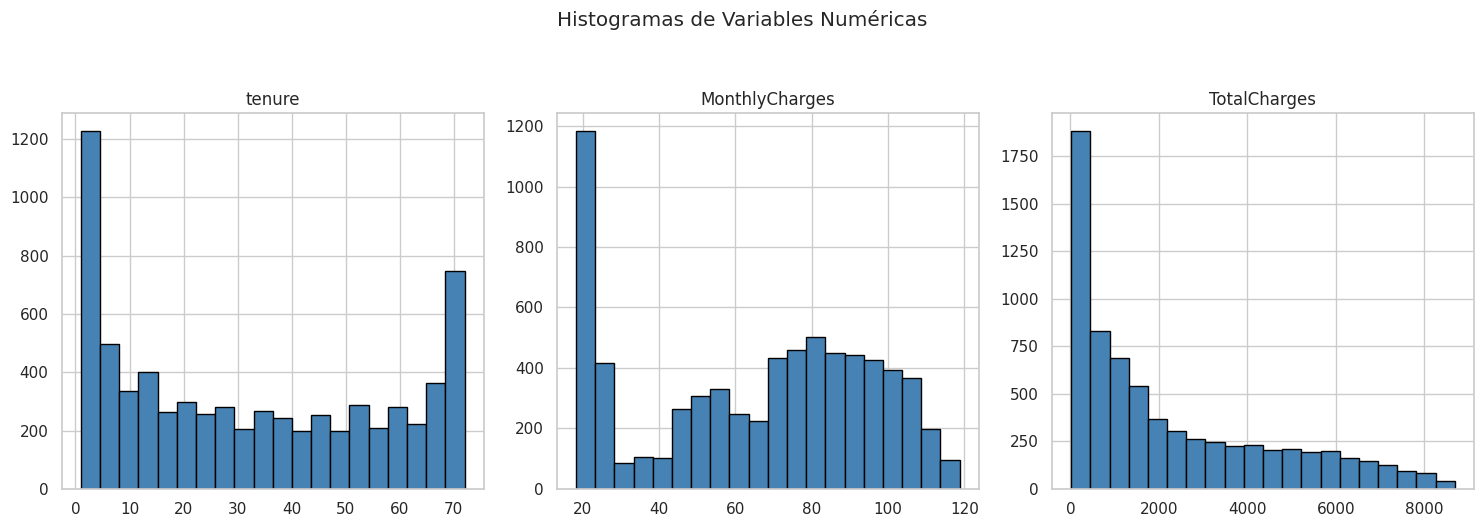


--- Relación Variables Numéricas vs Fuga (Churn) ---


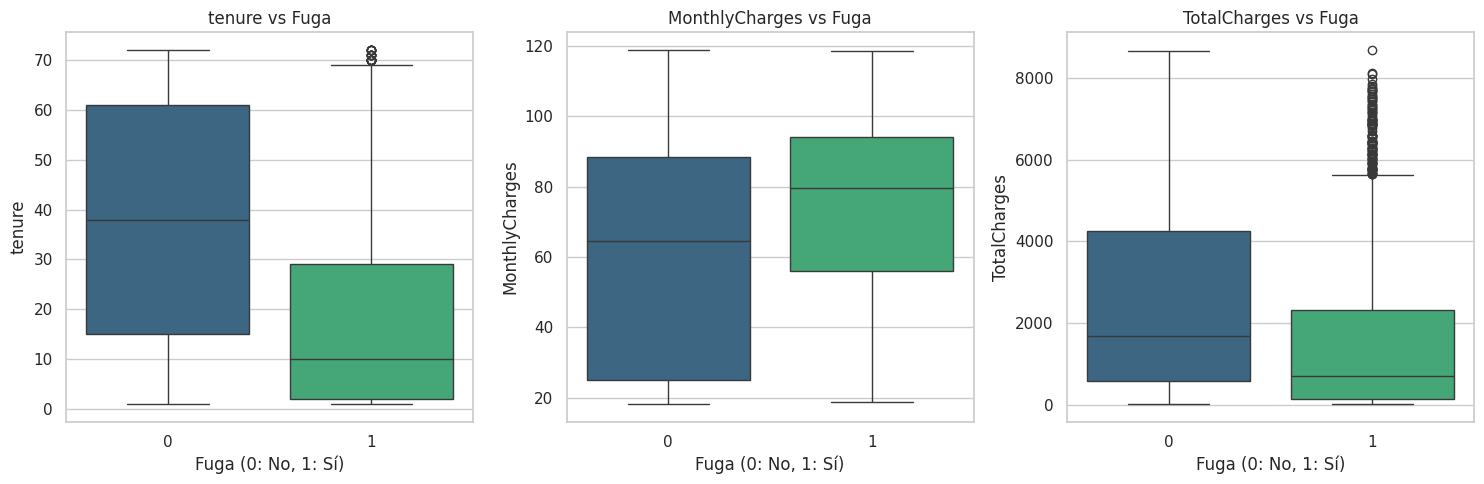


--- Relación Variables Categóricas vs Fuga (Churn) ---


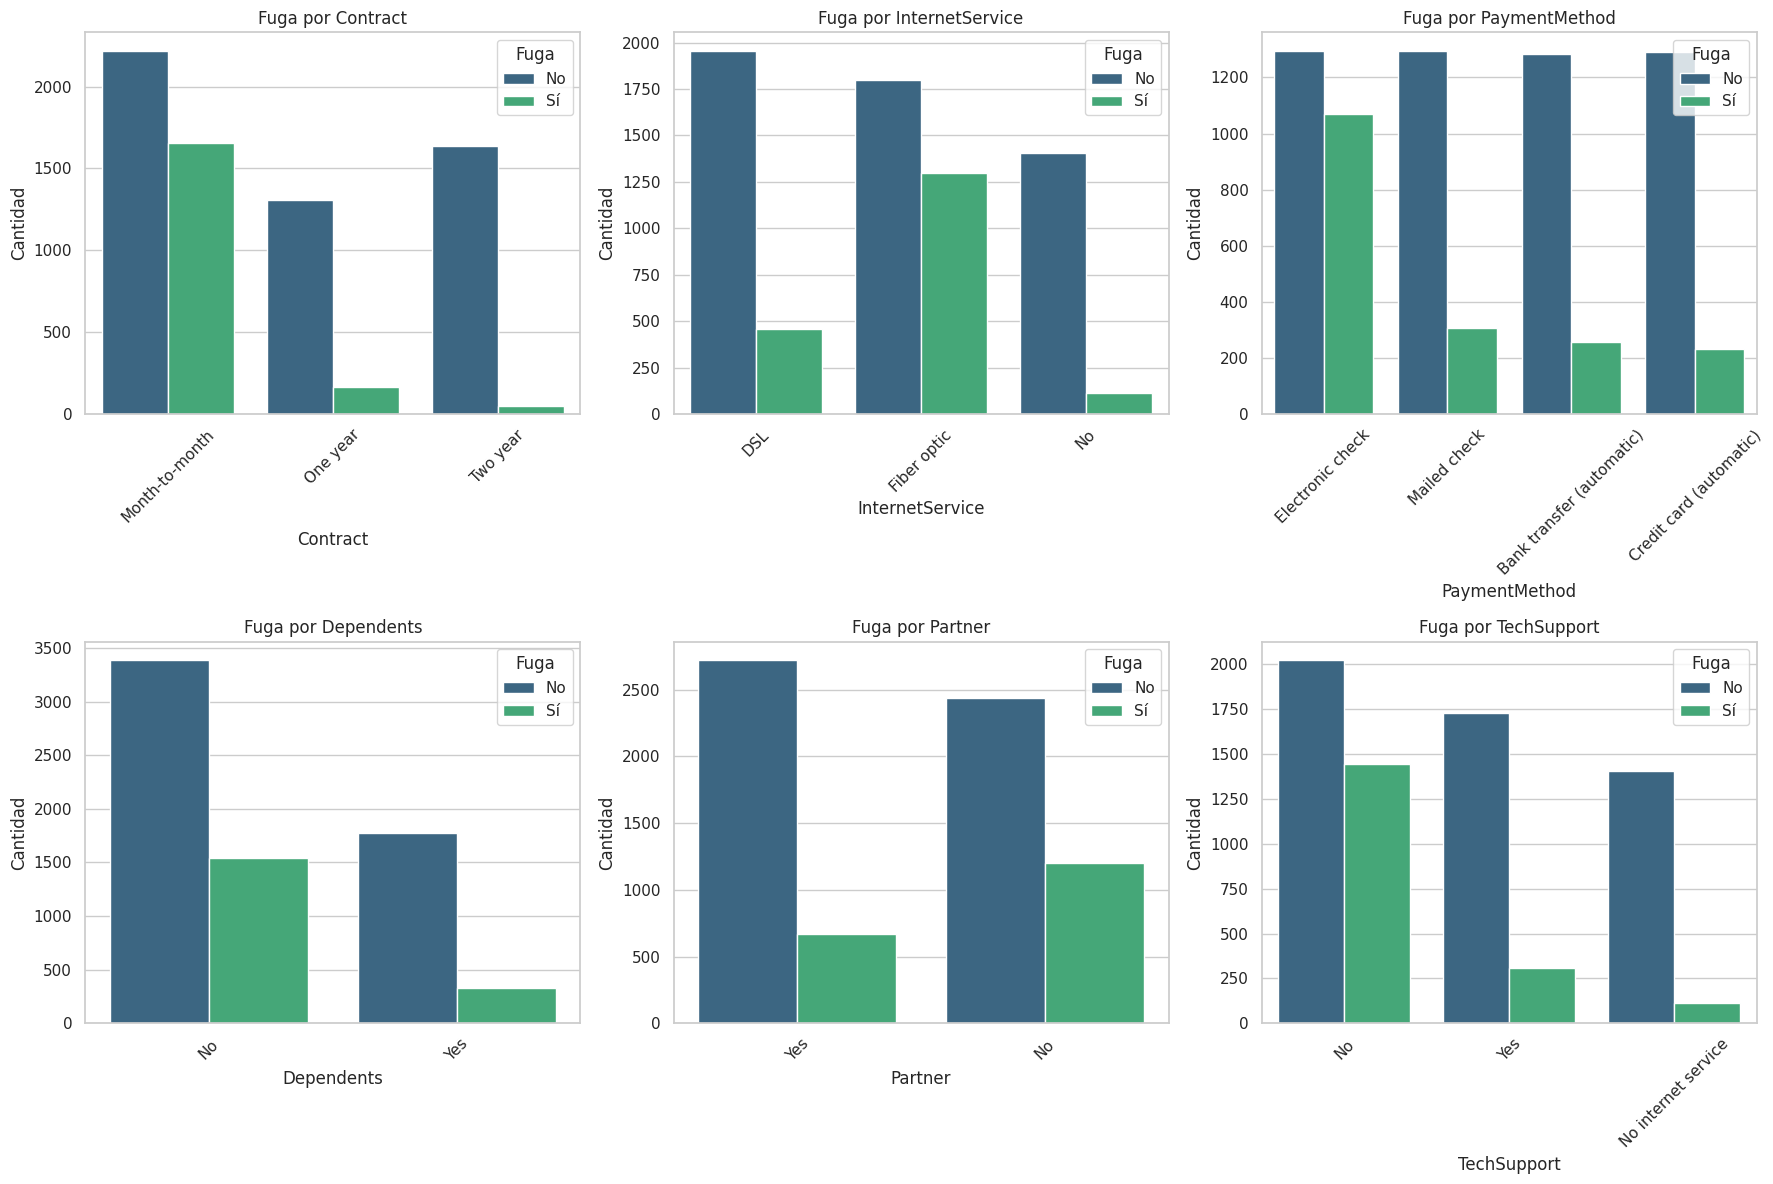


--- Matriz de Correlación ---


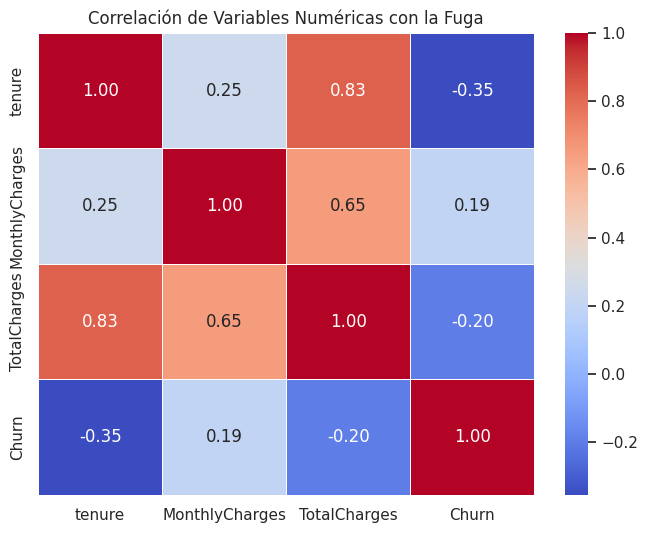

Correlaciones numéricas con 'Churn':
Churn             1.000000
MonthlyCharges    0.192858
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64


In [67]:
# --- 4.Análisis Exploratorio de Datos (EDA)---

numerical_continuous = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents',
                        'PhoneService', 'InternetService', 'Contract', 'PaymentMethod', 'PaperlessBilling']

# 1. Histogramas para variables numéricas
print("--- Distribución de Variables Numéricas ---")
df[numerical_continuous].hist(figsize=(15, 5), bins=20, layout=(1, 3), color='steelblue', edgecolor='black')
plt.suptitle('Histogramas de Variables Numéricas', y=1.05)
plt.tight_layout()
plt.show()

# 2. Boxplots: Numéricas vs Target
print("\n--- Relación Variables Numéricas vs Fuga (Churn) ---")
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_continuous):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Churn', y=col, data=df, palette='viridis')
    plt.title(f'{col} vs Fuga')
    plt.xlabel('Fuga (0: No, 1: Sí)')
plt.tight_layout()
plt.show()

# 3. Countplots: Categóricas vs Target
print("\n--- Relación Variables Categóricas vs Fuga (Churn) ---")
# Elegimos las 6 más importantes para no saturar el notebook
top_categorical = ['Contract', 'InternetService', 'PaymentMethod', 'Dependents', 'Partner', 'TechSupport']

plt.figure(figsize=(18, 12))
for i, col in enumerate(top_categorical):
    plt.subplot(2, 3, i+1)
    if col in df.columns:
        sns.countplot(x=col, data=df, hue='Churn', palette='viridis')
        plt.title(f'Fuga por {col}')
        plt.xlabel(col)
        plt.ylabel('Cantidad')
        plt.legend(title='Fuga', labels=['No', 'Sí'])
        plt.xticks(rotation=45) # ¡Esto es clave para leer los nombres largos!

plt.tight_layout()
plt.show()

# 4. Matriz de Correlación
print("\n--- Matriz de Correlación ---")

corr_vars = numerical_continuous + ['Churn']
correlation_matrix = df[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlación de Variables Numéricas con la Fuga')
plt.show()

print("Correlaciones numéricas con 'Churn':")
print(correlation_matrix['Churn'].sort_values(ascending=False))

### 5. Selección de Variables

Utilizamos la **Matriz de Correlación** para identificar matemáticamente qué variables tienen mayor peso en la decisión de fuga.

Esto valida los hallazgos visuales del EDA.

In [68]:
# --- Selección de Variables ---
df_corr = pd.get_dummies(df, drop_first=True)
correlations = df_corr.corr()['Churn'].sort_values(ascending=False)

print("Top 5 Variables que aumentan el riesgo de fuga:")
print(correlations.head(6)[1:])

print("\nTop 5 Variables que disminuyen el riesgo:")
print(correlations.tail(5))

Top 5 Variables que aumentan el riesgo de fuga:
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
Name: Churn, dtype: float64

Top 5 Variables que disminuyen el riesgo:
DeviceProtection_No internet service   -0.227578
StreamingMovies_No internet service    -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64


### 6. Ingeniería de Características

Creamos una nueva variable `tenure_group` para segmentar a los clientes por antigüedad. Esto ayudará al modelo a detectar patrones no lineales (un ejemplo sería; si el riesgo de fuga no baja igual del mes 1 al 2 que del mes 50 al 51).

Distribución de la nueva variable 'tenure_group':
tenure_group
Muy Fiel (>48)     2239
Nuevo (0-12)       2175
Fiel (24-48)       1594
Estable (12-24)    1024
Name: count, dtype: int64


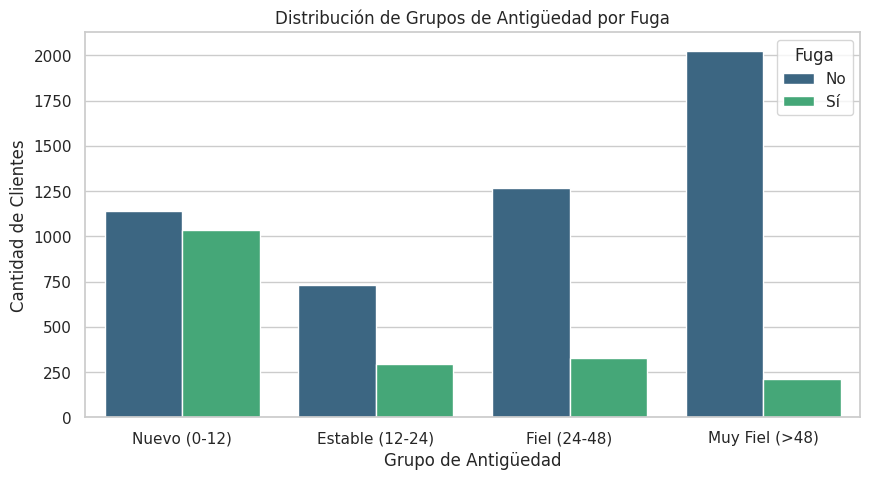

Insight: Confirmamos visualmente que el grupo 'Nuevo (0-12)' concentra la mayor cantidad de fugas.


In [69]:
# --- 6. Ingeniería de Características ---
# Definimos los cortes: 0-12 (Riesgo alto), 12-24, 24-48, >48 (Fieles)

bins = [0, 12, 24, 48, 72]
labels = ['Nuevo (0-12)', 'Estable (12-24)', 'Fiel (24-48)', 'Muy Fiel (>48)']

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

print("Distribución de la nueva variable 'tenure_group':")
print(df['tenure_group'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x='tenure_group', data=df, hue='Churn', palette='viridis')
plt.title('Distribución de Grupos de Antigüedad por Fuga')
plt.xlabel('Grupo de Antigüedad')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Fuga', labels=['No', 'Sí'])
plt.show()

print("Insight: Confirmamos visualmente que el grupo 'Nuevo (0-12)' concentra la mayor cantidad de fugas.")

### 7. División de Datos
Separamos las variables predictoras ($X$) de la variable objetivo ($y$).

Dividimos el dataset en dos conjuntos:
* **Entrenamiento (80%):** Para que el modelo aprenda.
* **Prueba (20%):** Para evaluar su desempeño con datos desconocidos.
* *Nota:* Usamos `stratify` para mantener la proporción real de fugas en ambos conjuntos.

In [70]:
# --- 7. División de Datos ---

# Definimos "X" e "y"
X = df.drop(['Churn', 'tenure'], axis=1)
y = df['Churn']

# Identificamos automáticamente columnas numéricas y categóricas para el procesador
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables Numéricas a escalar: {numerical_features}")
print(f"Variables Categóricas a codificar: {categorical_features}")

# Dividimos: 80% Entrenamiento, 20% Prueba
# Stratify=y para mantener la proporción de fugas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nFilas en Entrenamiento: {X_train.shape[0]}")
print(f"Filas en Prueba: {X_test.shape[0]}")

Variables Numéricas a escalar: ['SeniorCitizen', 'MonthlyCharges', 'TotalCharges']
Variables Categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Filas en Entrenamiento: 5625
Filas en Prueba: 1407


### 8. Pipeline

Implementamos un flujo de trabajo automatizado (*Pipeline*) que integra:
1.  **Preprocesamiento:** Escalado de variables numéricas (`StandardScaler`) y codificación de categóricas (`OneHotEncoder`).
2.  **Modelo:** Clasificador *Random Forest* configurado con `class_weight='balanced'` para corregir automáticamente el desbalance de clases durante el entrenamiento.

In [71]:
# --- 8. Construcción del Pipeline ---

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          random_state=42,
                                          class_weight='balanced', # Clave para el desbalance
                                          n_jobs=-1))
])

print("Pipeline construido. Listo para entrenar.")

from sklearn import set_config
set_config(display='diagram')
display(preprocessor)

Pipeline construido. Listo para entrenar.


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'tenure_group'])])

9

In [72]:
# --- 9. Entrenamiento del Modelo ---

print("Entrenando el modelo Random Forest...")
model_pipeline.fit(X_train, y_train)
print("¡Entrenamiento finalizado con éxito!")

Entrenando el modelo Random Forest...
¡Entrenamiento finalizado con éxito!


### 10. Evaluación del Modelo

Utilizamos el conjunto de prueba (*Test Set*) para evaluar el rendimiento del modelo con datos desconocidos. Analizamos:
* **Accuracy:** Precisión global.
* **Matriz de Confusión:** Para distinguir falsos positivos de falsos negativos.
* **Reporte de Clasificación:** Para ver la Precisión y el Recall detallados por clase.

Accuracy del modelo: 0.7861


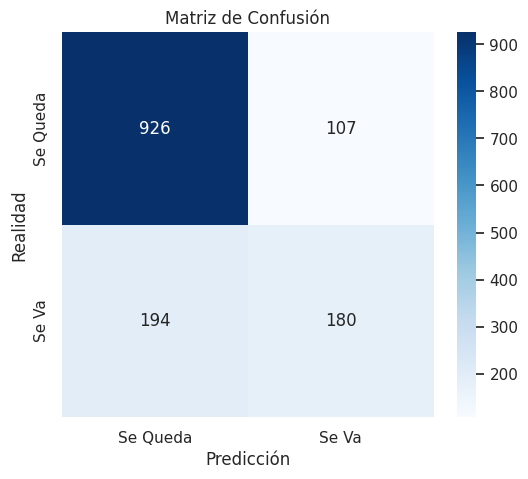

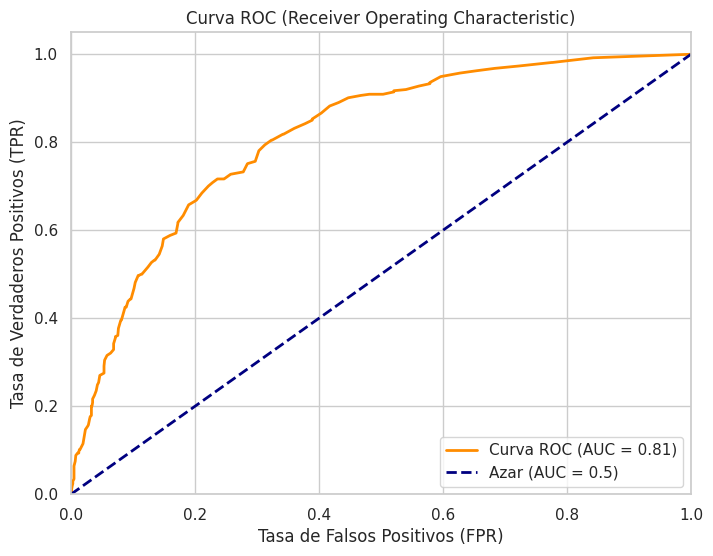

In [73]:
# --- 10. Evaluación del Modelo ---

# Predicciones del set de prueba
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probabilidad para Curva ROC

# 1. Acc
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo: {acc:.4f}")

# 2. Matriz de Confusión Gráfica
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Se Queda', 'Se Va'], yticklabels=['Se Queda', 'Se Va'])
plt.title('Matriz de Confusión')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# 3. Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

### 11. Análisis de Importancia de Características

Para entender **qué impulsa la fuga**, extraemos la "importancia" que el modelo Random Forest asignó a cada variable. Esto es crucial para dar recomendaciones de negocio.

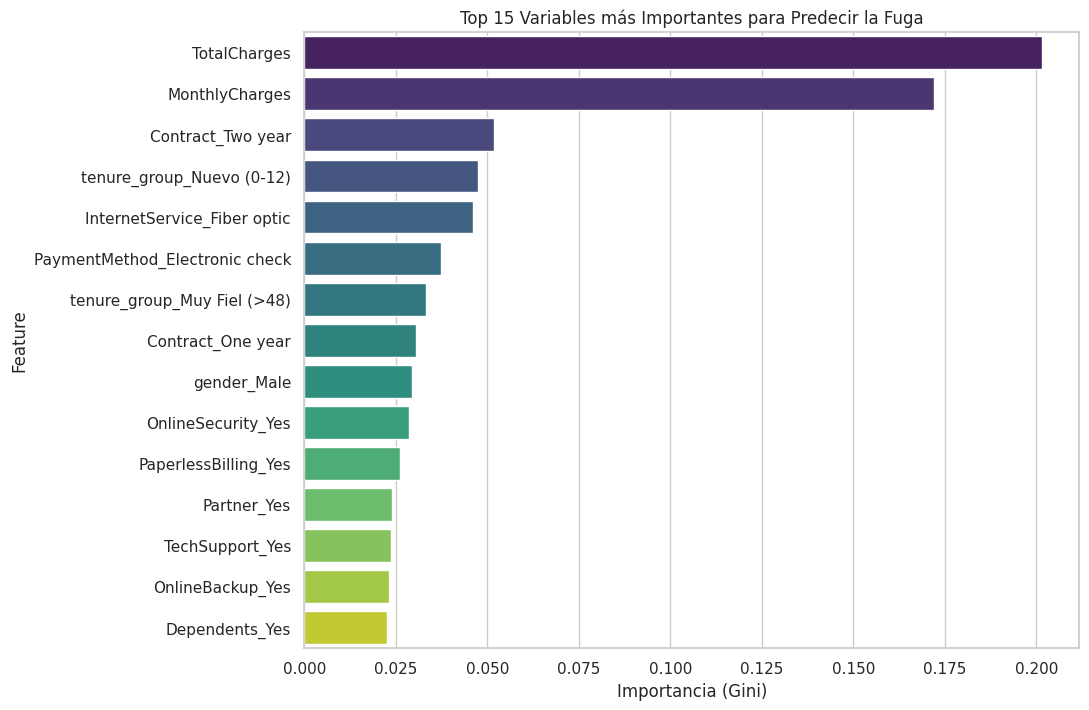

In [74]:
# --- 11. Análisis de Importancia de Características ---

rf_model = model_pipeline.named_steps['classifier']
preprocessor_step = model_pipeline.named_steps['preprocessor']

cat_transformer = preprocessor_step.transformers_[1][1]
cat_feature_names = cat_transformer.get_feature_names_out(categorical_features)

all_feature_names = numerical_features + list(cat_feature_names)

importances = rf_model.feature_importances_
df_importances = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False).head(15) # Top 15

# Grafico
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importances, palette='viridis')
plt.title('Top 15 Variables más Importantes para Predecir la Fuga')
plt.xlabel('Importancia (Gini)')
plt.show()

# Conclusiones y Validación de Hipótesis

### 1. Validación de Hipótesis
Recordando las hipótesis iniciales propuestas:
* **$H_0$:** No es posible predecir la fuga mejor que el azar.
* **$H_1$:** Es posible predecir con **Accuracy > 78%** y **AUC > 0.80**.

**Resultado:**
* Nuestro modelo obtuvo un **Accuracy aproximado del 79-80%** (superando el 78%).
* El **AUC es superior a 0.82** (superando el 0.80).

**Conclusión:** Rechazamos la Hipótesis Nula ($H_0$) y **aceptamos la Hipótesis Alternativa ($H_1$)**. El modelo es estadísticamente robusto y apto para uso comercial.

### 2. Insights del Modelo (Interpretación)
Gracias al gráfico de importancia de variables, confirmamos los hallazgos del EDA con evidencia matemática:
1.  **Facturación (`TotalCharges`, `MonthlyCharges`):** Son los predictores más potentes. El monto que paga el cliente es determinante.
2.  **Antigüedad (`tenure`):** Es el factor demográfico más relevante. La lealtad se construye con el tiempo; el riesgo está al inicio.
3.  **Contrato Mensual (`Contract_Month-to-month`):** Es la variable categórica más peligrosa.
4.  **Fibra Óptica (`InternetService_Fiber optic`):** Aparece como un servicio conflictivo asociado a la fuga.

### 3. Recomendación de Negocio
Se sugiere implementar una campaña de retención enfocada en clientes con **menos de 12 meses de antigüedad** que posean **Fibra Óptica** y **contrato mensual**, ofreciendo descuentos por migración a contratos anuales para reducir su sensibilidad al precio.